# Поиск объявлений по запросу: EDA + retrieval + reranker

Ноутбук реализует план: **EDA → несколько независимых retrieval-пулов → union → LTR-реранкер → top-50**.

Файлы `train.parquet`, `benchmark_queries.parquet`, `benchmark_items.parquet` должны лежать в одной папке с ноутбуком.

Зависимости: `pandas pyarrow scikit-learn scipy matplotlib tqdm` (обязательно), `lightgbm` или `catboost` (для реранкера), `pymorphy3` (опционально, лемматизация).

Порядок: 0 - конфиг и загрузка → 0.5 - **проверка качества данных и очистка** → 1 - нормализация текста (с кэшем) → 2 - EDA → 3 - split → 3.1 - метрики → 4 - индексы и retrievers → **5 - бейзлайны** → **6 - сортировка в параметрах поиска и подрезка кандидатов** → 7 - оффлайн-оценка retrievers → 8 - реранкер → 9 - предсказание для benchmark → **10 - итоговая таблица моделей**.

**Режим `FAST = True` (по умолчанию)**: меньше retrievers, короче char n-граммы, отсечение частых n-грамм, признаки считаются только для кандидатов, реранкер учится на hard negatives (топ-`MAX_NEG_PER_QUERY` по RRF), меньше деревьев. Для максимального качества поставь `FAST = False`.

## 0. Конфиг и загрузка

In [1]:
import time
start = time.perf_counter()

In [2]:
import re, gc, time, math, warnings
from pathlib import Path
from collections import Counter
import numpy as np, pandas as pd
import scipy.sparse as sp
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt

try:
    from tqdm.auto import tqdm
except ImportError:      # без tqdm ноутбук работает, просто без прогресс-баров
    class tqdm:
        def __init__(self, it=None, *a, **k): self.it = it
        def __iter__(self): return iter(self.it)
        def __len__(self): return len(self.it)
        def update(self, *a, **k): pass
        def close(self): pass
        def set_postfix(self, *a, **k): pass
        def set_description(self, *a, **k): pass

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 100); pd.set_option("display.width", 220); pd.set_option("display.max_columns", 60)

# ---------------- ПАРАМЕТРЫ ----------------
DATA_DIR = Path(".")
SEED = 42
FAST = True               # True: упрощенные/быстрые модели; False: полный набор retrievers и признаков
CLEAN = True              # применять очистку аномалий (см. раздел 0.5)
USE_CACHE = True          # кэшировать нормализованные таблицы (ускоряет повторные запуски)
TOP_FINAL = 50            # сколько объявлений отдаем на запрос
BATCH = 32                # батч запросов (плотные матрицы batch x n_items; при нехватке RAM уменьшить)
SPLIT_BY = "text"         # "text": делим по нормализованному тексту (строгий режим, запрос в val не виден в history)
                          # "group": делим по (query_id | текст+категория+локация); нужен, если benchmark сильно пересекается с train
N_RANK_QUERIES = 2000 if FAST else 4000    # запросов для обучения реранкера
N_VAL_QUERIES  = 800 if FAST else 1500     # запросов для оценки
USE_LEMMA = False         # лемматизация через pymorphy3 (медленно)
DESC_CHARS = 800 if FAST else 1500         # сколько символов описания использовать
RRF_K = 60

# Сортировка в search_infm_params_text и подрезка кандидатов (раздел 6)
SORT_KEY_RX = r"сортиров\w*|sort\w*|order_?by|order"   # ключ сортировки в строке параметров; поправь по реальному формату (см. вывод раздела 6)
NO_SORT = "__no_sort__"
PRUNE_BY_SORT = True      # срезать кандидатов по правилам из раздела 6 (правило создается, только если таргет ему соответствует всегда)
PRUNE_TOL = 0.0           # допустимая доля positive, нарушающих правило (0.0 = только "всегда")
PRUNE_MIN_Q = 100         # минимум пар train с данной сортировкой, чтобы доверять правилу
RULE_COLS = {}            # {значение сортировки: [числовые колонки, которые обязаны быть не NaN]}; заполняется в разделе 6
SORT_CODE = {}            # {значение сортировки: int} для признака реранкера; заполняется в разделе 6

# Метрики итоговой таблицы
METRIC_KS = (10, 50, 200)

# n-граммы / словари (главные потребители времени и памяти)
WORD_MIN_DF = 2
CHAR_MIN_DF = 3
CHAR_NGRAM = (3, 4) if FAST else (3, 5)
CHAR_MAX_DF = 0.3 if FAST else 1.0         # выкидываем n-граммы, встречающиеся почти везде (ускоряет умножение матриц)
CHAR_MAX_FEATURES = 300_000 if FAST else 1_000_000
QCHAR_NGRAM = (3, 4) if FAST else (3, 5)   # n-граммы для поиска похожих запросов
QCHAR_MAX_DF = 0.2 if FAST else 1.0
SIM_TOPK = 20 if FAST else 30              # сколько похожих исторических запросов учитываем

# Retrievers: имя -> (ключ скорера, сколько кандидатов берем в union)
RETRIEVERS_ALL = {
    "exact_hist": ("exact_hist", 50),
    "sim_hist":   ("sim_hist", 100),
    "sim_text":   ("sim_text", 100),
    "bm25_title": ("bm25_title", 100),
    "bm25_tp":    ("bm25_tp", 100),
    "bm25_full":  ("bm25_full", 100),
    "tf_word":    ("tf_word", 100),
    "tf_char":    ("tf_char", 100),
    "bm25_qe":    ("bm25_qe", 100),
    "bm25_cat":   ("bm25_cat", 100),
    "bm25_loc":   ("bm25_loc", 100),
}
FAST_SET = ["exact_hist", "sim_hist", "sim_text", "bm25_full", "tf_char", "bm25_qe", "bm25_cat"]
RETRIEVERS = {k: v for k, v in RETRIEVERS_ALL.items() if (not FAST or k in FAST_SET)}
EXTRA_SCORES = () if FAST else ("bm25_title", "tf_word")   # доп. скорера как признаки реранкера (не как retrievers)
NEED = {v[0] for v in RETRIEVERS.values()} | set(EXTRA_SCORES)
if {"bm25_cat", "bm25_loc"} & NEED: NEED.add("bm25_full")
RANK_DEPTH = 200 if FAST else 500          # глубина списков для оценки Recall@K
EVAL_KS = tuple(k for k in (10, 20, 50, 100, 200, 500) if k <= RANK_DEPTH)

# Реранкер
RERANK_TOPN = 200 if FAST else 500        # реранкер учится и применяется к топ-N кандидатов по RRF на запрос (одинаково в train / val / inference)
LGB_PARAMS = dict(n_estimators=200 if FAST else 400, learning_rate=0.08 if FAST else 0.05, num_leaves=31 if FAST else 63,
                  min_child_samples=30, subsample=0.8, subsample_freq=1, colsample_bytree=0.8, max_bin=63, n_jobs=-1)

# ---------------- ЗАГРУЗКА ----------------
t0 = time.time()
train = pd.read_parquet(DATA_DIR / "train.parquet")
bq = pd.read_parquet(DATA_DIR / "benchmark_queries.parquet")
bi = pd.read_parquet(DATA_DIR / "benchmark_items.parquet")
print(f"loaded in {time.time()-t0:.1f}s")

def schema(d):
    rows = {}
    for c in d.columns:
        try: nu = d[c].nunique()
        except Exception: nu = np.nan
        rows[c] = {"dtype": str(d[c].dtype), "nulls_%": round(100*d[c].isna().mean(), 2), "nunique": nu}
    return pd.DataFrame(rows).T

for name, d in [("train", train), ("benchmark_queries", bq), ("benchmark_items", bi)]:
    print(f"\n===== {name}: {d.shape} =====")
    display(schema(d)); display(d.head(3))

D:\konst\PycharmProjects\avito\.venv312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loaded in 16.0s

===== train: (497673, 19) =====


,dtype,nulls_%,nunique
search_query,str,0.0,74529
search_location_id,int64,0.0,2782
search_is_delivery_search,int32,0.0,2
search_infm_params_text,str,0.0,3724
search_category,int64,0.0,4
item_title_raw,str,0.0,210029
item_rating_reviews_count,float64,3.86,1372
item_rating,float64,5.67,8832
item_price,object,0.0,2992
item_microcat_id,int64,0.0,212


,search_query,search_location_id,search_is_delivery_search,search_infm_params_text,search_category,item_title_raw,item_rating_reviews_count,item_rating,item_price,item_microcat_id,item_longitude,item_location_id,item_latitude,item_is_phone_hidden,item_is_message_forbidden,item_infm_params_text,item_id,item_description_raw,item_category_id
0,скупка телевизоров,652430,0,,114,Скупка б/у техники,91.0,4.989011,1.000000000000000,2303374,39.712818145751953,652430,54.629230499267578,True,False,"Вид услуги Место оказания услуг Первомайский пр-т, 66 Тип стоимости за услугу Работаете с юрлица...",e8b685dffe1a408e,"Скупаю практически любую современную новую и б/у технику(обязательно рабочую), до 80% от рыночно...",114
1,автоподбор,640860,0,Рейтинг пользователя 4 звезды и выше,114,Автоподбор Разовый осмотр автомобиля,462.0,4.982684,3500.000000000000000,2303374,44.051009999999998,640860,56.273389999999999,False,False,"Вид услуги Место оказания услуг Нижний Новгород, Советский район, жилой комплекс Новая Кузнечиха...",92e1b0446f827b59,🚗 Автоподбор и выездная диагностика автомобиля в Нижнем Новгороде и области.\n\n🫴 Помогу подобра...,114
2,баня на дровах,653240,0,"Онлайн-запись Тип услуги СПА-услуги, массаж Вид услуги Красота, здоровье",114,"Баня на дровах ""Прованс"" на Цветочной",NaN,NaN,1600.000000000000000,86469,30.128784180000000,653240,59.783687590000000,False,False,"Вид услуги Красота, здоровье Место оказания услуг Санкт-Петербург, садоводческое некоммерческое ...",624846856ce81d69,"В ритме современной жизни так сложно найти момент, чтобы остановиться: выключить телефон, отлож...",114



===== benchmark_queries: (2452, 6) =====


,dtype,nulls_%,nunique
query_id,str,0.0,2452
search_query,str,0.0,2452
search_location_id,int64,0.0,273
search_is_delivery_search,int32,0.0,1
search_infm_params_text,str,0.0,132
search_category,int64,0.0,2


,query_id,search_query,search_location_id,search_is_delivery_search,search_infm_params_text,search_category
0,70DfDUpwjxB4lzFd,перевозки владикавказ тбилиси,649820,0,,114
1,JTrdTaZJvSiLPkXj,обзвон по базе,107620,0,Вид услуги Деловые услуги,114
2,LZCZNoVG4AFUkVRJ,липоредукция подбородка,637640,0,"Вид услуги Красота, здоровье",114



===== benchmark_items: (189212, 14) =====


,dtype,nulls_%,nunique
item_title_raw,str,0.0,119952
item_rating_reviews_count,float64,6.14,1170
item_rating,float64,9.32,6007
item_price,object,0.0,2949
item_microcat_id,int64,0.0,752
item_longitude,object,0.0,120004
item_location_id,int64,0.0,2877
item_latitude,object,0.0,119778
item_is_phone_hidden,bool,0.0,2
item_is_message_forbidden,bool,0.0,2


,item_title_raw,item_rating_reviews_count,item_rating,item_price,item_microcat_id,item_longitude,item_location_id,item_latitude,item_is_phone_hidden,item_is_message_forbidden,item_infm_params_text,item_id,item_description_raw,item_category_id
0,Ремонт/выкуп компьют. и ноутбуков с выездом на дом,57.0,5.0,500.000000000000000,2097573,42.047193961004901,631060,44.228180450924000,False,False,Вид услуги Компьютерная помощь Место оказания услуг пр-т Ленина Тип стоимости за услугу Начальна...,111eb8b979577d79,"Выезд на дом в любое время, вплоть до 23:00\n\n● Диагностика устройств;\n\n● Чистка от пыли и за...",114
1,Обучение ребенка чтению,7.0,5.0,900.000000000000000,86453,49.627391820000000,631870,58.627609249999999,False,False,"Вид услуги Обучение, курсы Место оказания услуг ул. Чернышевского, 35 Тип услуги Детское развити...",75fc8e10f5a66fc4,"Дорогие родители и маленькие книголюбы! \n\nЯ, детский психолог/нейропсихолог, рада пригласить в...",114
2,Афрокудри 5+,14.0,5.0,1000.000000000000000,86467,40.936892000000000,628500,56.990307000000001,True,False,"Вид услуги Красота, здоровье Место оказания услуг городской округ Иваново, Фрунзенский район Тип...",3f6ae81704565b9c,"ВНИМАНИЕ Укладка !!!! 🥳\n\nАФРОкудри отличный вариант замены хим завивки, если хочется поменять ...",114


In [3]:
# import pandas as pd
#
# df = pd.read_parquet('train.parquet')  # Читаем Parquet
# df.to_csv('train.csv', index=False)     # Записываем в CSV (index=False убирает лишний столбец с индексами)


### Соответствие колонок
Логические имена → реальные колонки. Если авто-подбор ошибся - впиши в `OVERRIDE`, например `{"i_id": "id"}`.

In [4]:
CANDS = {
    "q_text":  ["search_query", "query", "query_text"],
    "q_cat":   ["search_category", "search_category_id"],
    "q_loc":   ["search_location_id", "search_location"],
    "q_params":["search_infm_params_text"],
    "q_lat":   ["search_latitude", "search_lat"],
    "q_lon":   ["search_longitude", "search_lon"],
    "q_id":    ["query_id", "search_id", "search_query_id", "request_id"],
    "i_id":    ["item_id", "id", "itemid"],
    "i_title": ["item_title_raw", "item_title"],
    "i_desc":  ["item_description_raw", "item_description"],
    "i_params":["item_infm_params_text"],
    "i_cat":   ["item_category_id"],
    "i_micro": ["item_microcat_id"],
    "i_loc":   ["item_location_id"],
    "i_lat":   ["item_latitude", "item_lat", "latitude"],
    "i_lon":   ["item_longitude", "item_lon", "longitude"],
}
OVERRIDE = {}

def resolve(cols, keys):
    return {k: OVERRIDE.get(k, next((c for c in CANDS[k] if c in cols), None)) for k in keys}

C  = resolve(set(train.columns), CANDS)                                   # train: и q_*, и i_*
CB = resolve(set(bq.columns), [k for k in CANDS if k.startswith("q_")])   # benchmark_queries
CI = resolve(set(bi.columns),  [k for k in CANDS if k.startswith("i_")])  # benchmark_items
print("train :", C); print("bq    :", CB); print("bi    :", CI)
assert C["q_text"] and C["i_id"], "Не нашли search_query / item_id: заполни OVERRIDE"

# числовые item-признаки (цена, рейтинг, число отзывов и т.п.) - берем автоматически
USED = {v for v in C.values() if v}
_PLACEHOLDER = {"", "none", "nan", "null", "n/a", "na", "-"}

def to_num(s):
    """В float. 'None' / 'nan' / '' / любой нечисловой мусор -> NaN. Строки НЕ удаляем (у услуги может не быть рейтинга)."""
    if pd.api.types.is_numeric_dtype(s) and not pd.api.types.is_bool_dtype(s): return s.astype("float64")
    s = s.astype("object").map(lambda x: np.nan if x is None or (isinstance(x, str) and x.strip().lower() in _PLACEHOLDER) else x)
    return pd.to_numeric(s, errors="coerce").astype("float64")

def is_numlike(s, n=20000):
    """Числовая ли колонка (в т.ч. object со значениями 'None'/NaN, где остальное - числа, например рейтинг)"""
    if pd.api.types.is_bool_dtype(s): return False
    if pd.api.types.is_numeric_dtype(s): return True
    try:
        smp = s.dropna()
        if len(smp) > n: smp = smp.sample(n, random_state=SEED)
        smp = smp[~smp.astype(str).str.strip().str.lower().isin(_PLACEHOLDER)]
        return len(smp) > 0 and pd.to_numeric(smp, errors="coerce").notna().mean() >= 0.9
    except Exception:
        return False

NUM_COLS = [c for c in train.columns if c.startswith("item_") and c not in USED
            and c in bi.columns and is_numlike(train[c])][:12]
print("numeric item cols:", NUM_COLS)

train : {'q_text': 'search_query', 'q_cat': 'search_category', 'q_loc': 'search_location_id', 'q_params': 'search_infm_params_text', 'q_lat': None, 'q_lon': None, 'q_id': None, 'i_id': 'item_id', 'i_title': 'item_title_raw', 'i_desc': 'item_description_raw', 'i_params': 'item_infm_params_text', 'i_cat': 'item_category_id', 'i_micro': 'item_microcat_id', 'i_loc': 'item_location_id', 'i_lat': 'item_latitude', 'i_lon': 'item_longitude'}
bq    : {'q_text': 'search_query', 'q_cat': 'search_category', 'q_loc': 'search_location_id', 'q_params': 'search_infm_params_text', 'q_lat': None, 'q_lon': None, 'q_id': 'query_id'}
bi    : {'i_id': 'item_id', 'i_title': 'item_title_raw', 'i_desc': 'item_description_raw', 'i_params': 'item_infm_params_text', 'i_cat': 'item_category_id', 'i_micro': 'item_microcat_id', 'i_loc': 'item_location_id', 'i_lat': 'item_latitude', 'i_lon': 'item_longitude'}
numeric item cols: ['item_rating_reviews_count', 'item_rating', 'item_price']


## 0.5 Проверка качества данных

Ищем: полные дубликаты, пропуски, константные колонки, отрицательные/нулевые/inf/экстремальные числа, невозможные координаты, пустые и «мусорные» тексты (mojibake, HTML, заглушки), конфликты в идентификаторах. Числа по текстовым проверкам считаются на выборке до 200k строк.

In [5]:
NCHK = 200_000
RX = {
    "пустой/пробельный текст":   re.compile(r"^\s*$"),
    "заглушка (nan/none/-/0)":   re.compile(r"^\s*(nan|none|null|n/a|undefined|-+|—|\.+|0)\s*$", re.I),
    "нет букв и цифр":           re.compile(r"^[^0-9A-Za-zА-Яа-яЁё]+$"),
    "mojibake / битая кодировка": re.compile("[ÐÑÃÂ][\u0080-\u00bf]|\ufffd"),
    "HTML-теги/сущности":        re.compile(r"<[a-zA-Z/][^>]*>|&[a-z]{2,6};"),
    "управляющие символы":       re.compile(r"[\x00-\x08\x0b\x0c\x0e-\x1f]"),
}
INFO_RX = {"URL": re.compile(r"https?://|www\."), "телефон": re.compile(r"\+?\d[\d\-\s()]{9,}\d")}
GEO_KEYS = {"lat": 90, "lon": 180}

def full_dup_mask(df):
    try: return df.duplicated().values
    except TypeError:   # есть list/ndarray-колонки
        return pd.util.hash_pandas_object(df.astype(str), index=False).duplicated().values

def quality_report(df, name, Cmap):
    iss = []; n = len(df)
    def add(col, check, cnt, tot=None):
        tot = tot or n
        if cnt: iss.append((name, col, check, int(cnt), round(100 * cnt / max(tot, 1), 3), tot))
    add("<все колонки>", "полные дубликаты строк", full_dup_mask(df).sum())
    for c in tqdm(df.columns, desc=f"quality {name}", leave=False):
        s = df[c]
        add(c, "пропуски (NaN/None)", s.isna().sum())
        try:
            if s.nunique(dropna=False) <= 1: add(c, "константная колонка", n)
        except TypeError: pass
        if pd.api.types.is_bool_dtype(s): continue
        if pd.api.types.is_numeric_dtype(s):
            v = s.astype("float64"); f = v.replace([np.inf, -np.inf], np.nan).dropna()
            add(c, "inf/-inf", np.isinf(v).sum())
            is_id = c.endswith("_id") or c == "id"
            add(c, "отрицательные значения", (f < 0).sum())
            if re.search(r"price|cost|amount|sum", c, re.I): add(c, "нулевая цена/сумма", (f == 0).sum())
            if len(f) > 20 and not is_id and f.nunique() > 10:
                q1, q3 = f.quantile([.25, .75]); iqr = q3 - q1
                if iqr > 0: add(c, "экстремальные выбросы (> Q3+5*IQR или < Q1-5*IQR)", ((f > q3 + 5 * iqr) | (f < q1 - 5 * iqr)).sum(), len(f))
                med = f.median(); mx = f.max()
                if med > 0 and mx / med > 1e4: add(c, f"max/median > 1e4 (max={mx:.3g}, median={med:.3g})", 1)
        elif s.dtype == object or pd.api.types.is_string_dtype(s):
            smp = s.dropna()
            if len(smp) > NCHK: smp = smp.sample(NCHK, random_state=SEED)
            st = smp.astype(str)
            for lab, rx in RX.items(): add(c, lab, st.str.contains(rx).sum(), len(st))
            for lab, rx in INFO_RX.items():
                if c in (Cmap.get("i_desc"), Cmap.get("i_title")): add(c, "инфо: " + lab, st.str.contains(rx).sum(), len(st))
            if c in (Cmap.get("q_text"),):
                ln = st.str.len(); add(c, "запрос длиннее 200 символов", (ln > 200).sum(), len(st)); add(c, "запрос из 1 символа", (ln <= 1).sum(), len(st))
    # координаты
    for la, lo in (("q_lat", "q_lon"), ("i_lat", "i_lon")):
        a, b = Cmap.get(la), Cmap.get(lo)
        if a in df.columns and b in df.columns:
            x, y = pd.to_numeric(df[a], errors="coerce"), pd.to_numeric(df[b], errors="coerce")
            add(a, "широта вне [-90, 90]", (x.abs() > 90).sum()); add(b, "долгота вне [-180, 180]", (y.abs() > 180).sum())
            add(a + "/" + b, "координаты (0, 0)", ((x == 0) & (y == 0)).sum())
            add(a + "/" + b, "одна из координат пропущена", (x.isna() ^ y.isna()).sum())
    return iss

allc = []
allc += quality_report(train, "train", C)
allc += quality_report(bq, "benchmark_queries", {k: v for k, v in CB.items()})
allc += quality_report(bi, "benchmark_items", {k: v for k, v in CI.items()})

# --- конфликты идентификаторов ---
n_tr = len(train)
g = train.groupby(C["i_id"])
for lab, key in (("i_title", "разные title у одного item_id"), ("i_cat", "разные item_category у одного item_id"), ("i_loc", "разные item_location у одного item_id")):
    if C.get(lab):
        nu = g[C[lab]].nunique(dropna=False); allc.append(("train", C["i_id"], "конфликт: " + key, int((nu > 1).sum()), round(100 * (nu > 1).mean(), 3), int(len(nu))))
if C.get("q_text") and C.get("q_id"):
    nu = train.groupby(C["q_id"])[C["q_text"]].nunique(dropna=False); allc.append(("train", C["q_id"], "конфликт: разные тексты у одного query_id", int((nu > 1).sum()), round(100 * (nu > 1).mean(), 3), int(len(nu))))
dpi = bi[CI["i_id"]].duplicated().sum() if CI.get("i_id") else 0
allc.append(("benchmark_items", CI.get("i_id"), "дубли item_id", int(dpi), round(100 * dpi / len(bi), 3), len(bi)))
if C.get("q_id") is None: allc.append(("train", "-", "нет колонки query_id (группируем по тексту)", 1, 0.0, 1))
dpp = train.duplicated([C["q_text"], C["i_id"]]).sum()
allc.append(("train", "query+item", "повторы пары (query, item), не обязательно полные дубли строк", int(dpp), round(100 * dpp / n_tr, 3), n_tr))

ISSUES = pd.DataFrame(allc, columns=["dataset", "column", "check", "count", "share_%", "checked"]).query("count > 0")
ISSUES = ISSUES.sort_values("share_%", ascending=False).reset_index(drop=True)
print(f"найдено проблем: {len(ISSUES)}")
display(ISSUES)

найдено проблем: 38


,dataset,column,check,count,share_%,checked
0,benchmark_queries,search_is_delivery_search,константная колонка,2452,100.000,2452
1,benchmark_queries,search_infm_params_text,пустой/пробельный текст,1546,63.051,2452
2,train,search_infm_params_text,пустой/пробельный текст,65928,32.964,200000
3,train,query+item,"повторы пары (query, item), не обязательно полные дубли строк",52412,10.531,497673
4,benchmark_items,item_rating,пропуски (NaN/None),17631,9.318,189212
5,train,<все колонки>,полные дубликаты строк,30619,6.152,497673
6,benchmark_items,item_rating_reviews_count,пропуски (NaN/None),11615,6.139,189212
7,train,item_rating,пропуски (NaN/None),28232,5.673,497673
8,benchmark_items,item_rating,экстремальные выбросы (> Q3+5*IQR или < Q1-5*IQR),8643,5.037,171581
9,train,item_rating,экстремальные выбросы (> Q3+5*IQR или < Q1-5*IQR),20227,4.309,469441


### Очистка (`CLEAN=True`)
* `train` / `benchmark_items`: удаляем полные дубликаты строк и строки без `item_id`; `train` - также строки с пустым запросом.
* `benchmark_queries`: **строки не удаляем** (на каждый запрос нужен ответ), только чиним координаты.
* **Строки с NaN/None в числовых колонках (рейтинг, цена и т.п.) НЕ удаляем** - у услуги может не быть рейтинга; такие значения остаются `NaN` и попадают в модель как есть (LightGBM/CatBoost/HGB умеют работать с пропусками). Колонки вида `'None'`/`''` приводятся к числу через `to_num`.
* Отрицательные значения в «неотрицательных» числовых колонках (price/count/review/...) и `±inf` → `NaN`; координаты вне диапазона или `(0, 0)` → `NaN`. Выбросы не режем (деревья к ним устойчивы), они просто отражены в отчете.

In [6]:
NONNEG = re.compile(r"price|cost|amount|count|review|view|age|qty|photo|image|sum", re.I)

def fix_geo(df, lat, lon):
    if lat in df.columns and lon in df.columns:
        x, y = pd.to_numeric(df[lat], errors="coerce"), pd.to_numeric(df[lon], errors="coerce")
        bad = (x.abs() > 90) | (y.abs() > 180) | ((x == 0) & (y == 0)) | (x.isna() ^ y.isna())
        df[lat] = x.mask(bad); df[lon] = y.mask(bad); return int(bad.sum())
    return 0

def fix_numeric(df, cols):
    # NaN/None (например, нет рейтинга) - НЕ ошибка: строки остаются. Чиним только inf и отрицательные в "неотрицательных" колонках.
    n = 0
    for c in cols:
        if c in df.columns:
            v = to_num(df[c]); bad = np.isinf(v) | ((v < 0) if NONNEG.search(c) else False)
            n += int(bad.sum()); df[c] = v.mask(bad)
    return n

if CLEAN:
    log = {}
    n0 = len(train)
    train = train[train[C["i_id"]].notna()]
    if C.get("q_text"): train = train[train[C["q_text"]].astype(str).str.strip().ne("") & train[C["q_text"]].notna()]
    train = train[~full_dup_mask(train)].reset_index(drop=True); log["train: удалено строк"] = n0 - len(train)
    n0 = len(bi); bi = bi[bi[CI["i_id"]].notna()]; bi = bi[~full_dup_mask(bi)].reset_index(drop=True); log["benchmark_items: удалено строк"] = n0 - len(bi)
    log["train: исправлено чисел"] = fix_numeric(train, NUM_COLS); log["benchmark_items: исправлено чисел"] = fix_numeric(bi, NUM_COLS)
    log["train: исправлено координат item"] = fix_geo(train, C.get("i_lat"), C.get("i_lon")); log["train: исправлено координат query"] = fix_geo(train, C.get("q_lat"), C.get("q_lon"))
    log["benchmark_items: исправлено координат"] = fix_geo(bi, CI.get("i_lat"), CI.get("i_lon")); log["benchmark_queries: исправлено координат"] = fix_geo(bq, CB.get("q_lat"), CB.get("q_lon"))
    display(pd.Series(log, name="очистка").to_frame())
    if NUM_COLS:
        print("доля NaN в числовых колонках (строки сохранены):")
        display(pd.DataFrame({"train": train[NUM_COLS].isna().mean(), "benchmark_items": bi[NUM_COLS].isna().mean()}).round(3))
    print("train:", train.shape, "| benchmark_items:", bi.shape, "| benchmark_queries:", bq.shape)

,очистка
train: удалено строк,30619
benchmark_items: удалено строк,0
train: исправлено чисел,31090
benchmark_items: исправлено чисел,15248
train: исправлено координат item,78
train: исправлено координат query,0
benchmark_items: исправлено координат,61
benchmark_queries: исправлено координат,0


доля NaN в числовых колонках (строки сохранены):


,train,benchmark_items
item_rating_reviews_count,0.038,0.061
item_rating,0.056,0.093
item_price,0.067,0.081


train: (467054, 19) | benchmark_items: (189212, 14) | benchmark_queries: (2452, 6)


## 1. Нормализация текста и построение таблиц items / pairs

In [7]:
_re_clean = re.compile(r"[^0-9a-zа-я]+")
try:
    if not USE_LEMMA: raise ImportError
    import pymorphy3
    from functools import lru_cache
    _morph = pymorphy3.MorphAnalyzer()
    @lru_cache(maxsize=500_000)
    def _lem(w): return _morph.parse(w)[0].normal_form
except ImportError:
    _lem = None
print("lemmatization:", _lem is not None)

def norm(s, lemma=False):
    """lower, ё->е, только буквы/цифры, схлопнутые пробелы, (опц.) лемматизация"""
    if s is None or (isinstance(s, float) and math.isnan(s)): return ""
    s = _re_clean.sub(" ", str(s).lower().replace("ё", "е")).strip()
    if lemma and _lem is not None: s = " ".join(_lem(w) for w in s.split())
    return s

def tmap(s, fn, desc=""):
    """map с прогресс-баром"""
    return pd.Series([fn(x) for x in tqdm(list(s), desc=desc, leave=False)], index=s.index)

_SORT_VAL = re.compile(r"(?:" + SORT_KEY_RX + r")\W{0,4}([^;,|&\n\"'}\]]{1,40})", re.I)
def extract_sort(s):
    """Значение сортировки из сырой строки search_infm_params_text; NO_SORT, если сортировки нет"""
    if not isinstance(s, str): return NO_SORT
    m = _SORT_VAL.search(s)
    if not m: return NO_SORT
    v = norm(m.group(1)); return v if v else NO_SORT

def _col(df, C, k, default=None):
    c = C.get(k)
    return df[c] if c and c in df.columns else pd.Series([default]*len(df), index=df.index)

def build_items(df, C, num_cols=()):
    """Уникальные объявления + нормализованные текстовые поля."""
    d = df.drop_duplicates(C["i_id"]).reset_index(drop=True)
    it = pd.DataFrame({"item_id": d[C["i_id"]].astype(str).values})
    it["t"] = tmap(_col(d, C, "i_title", ""), lambda s: norm(s, True), "items: title")
    it["p"] = tmap(_col(d, C, "i_params", ""), lambda s: norm(s, True), "items: params")
    it["d"] = tmap(_col(d, C, "i_desc", ""), lambda s: norm(s[:DESC_CHARS]) if isinstance(s, str) else "", "items: desc")
    it["tp"] = (it.t + " " + it.p).str.strip()
    it["full"] = (it.tp + " " + it.d).str.strip()
    it["t_tokens"] = it.t.str.split()
    it["t_len"] = it.t_tokens.map(len).astype(np.float32)
    it["cat"] = _col(d, C, "i_cat").astype(str).values
    it["micro"] = _col(d, C, "i_micro").astype(str).values
    it["loc"] = _col(d, C, "i_loc").astype(str).values
    it["lat"] = pd.to_numeric(_col(d, C, "i_lat"), errors="coerce").values
    it["lon"] = pd.to_numeric(_col(d, C, "i_lon"), errors="coerce").values
    for c in num_cols:
        it[c] = to_num(d[c]).values if c in d.columns else np.nan   # NaN/None (нет рейтинга) остаются NaN
    return it

def norm_queries(df, C):
    q = pd.DataFrame(index=df.index)
    q["qtext"] = tmap(_col(df, C, "q_text", ""), lambda s: norm(s, True), "queries: text")
    q["qcat"] = _col(df, C, "q_cat").astype(str)
    q["qloc"] = _col(df, C, "q_loc").astype(str)
    q["qparams"] = tmap(_col(df, C, "q_params", ""), norm, "queries: params")
    q["qsort"] = tmap(_col(df, C, "q_params", ""), extract_sort, "queries: sort")
    q["qlat"] = pd.to_numeric(_col(df, C, "q_lat"), errors="coerce")
    q["qlon"] = pd.to_numeric(_col(df, C, "q_lon"), errors="coerce")
    q["qid_raw"] = _col(df, C, "q_id") if C.get("q_id") else np.arange(len(df))
    return q

import pickle
t0 = time.time()
_key = dict(ver=3, lemma=USE_LEMMA and _lem is not None, desc=DESC_CHARS, split=SPLIT_BY, clean=CLEAN, shapes=(train.shape, bi.shape, bq.shape), num=tuple(NUM_COLS))
_cache = DATA_DIR / "_prep_cache.pkl"
if USE_CACHE and _cache.exists():
    with open(_cache, "rb") as fh: _obj = pickle.load(fh)
    if _obj.get("key") == _key: train_items, pool_items, pairs, bqn = _obj["train_items"], _obj["pool_items"], _obj["pairs"], _obj["bqn"]; print("prep loaded from cache")
    else: _obj = None
else: _obj = None
if _obj is None:
    train_items = build_items(train, C, NUM_COLS)
    pool_items  = build_items(bi, CI, NUM_COLS)
    # pairs: query -> chosen item
    pairs = norm_queries(train, C)
    _imap = pd.Series(np.arange(len(train_items)), index=train_items.item_id)
    pairs["titem"] = train[C["i_id"]].astype(str).map(_imap).values
    if SPLIT_BY == "group":
        pairs["unit"] = (pairs.qid_raw.astype(str) if C["q_id"] else pairs.qtext + "|" + pairs.qcat + "|" + pairs.qloc)
    else:
        pairs["unit"] = pairs.qtext
    pairs = pairs[pairs.qtext.str.len() > 0].drop_duplicates(["unit", "titem"]).reset_index(drop=True)
    bqn = norm_queries(bq, CB)
    if USE_CACHE:
        with open(_cache, "wb") as fh: pickle.dump(dict(key=_key, train_items=train_items, pool_items=pool_items, pairs=pairs, bqn=bqn), fh, protocol=4)
print(f"items: train {len(train_items):,} | benchmark {len(pool_items):,} | pairs {len(pairs):,} | units {pairs.unit.nunique():,}  ({time.time()-t0:.0f}s)")

lemmatization: False
prep loaded from cache
items: train 344,825 | benchmark 189,212 | pairs 445,173 | units 73,706  (10s)


## 2. EDA

=== 1. Размеры ===
train строк: 467,054 | уникальных нормализ. query: 73,706 | уникальных items: 344,825 | уникальных пар: 445,173
benchmark queries: 2,452 (уникальных текстов 2,451) | benchmark items: 189,212

=== 2. Positive-объявлений на запрос (unit) ===
count    73706.00
mean         6.04
std         50.62
min          1.00
50%          1.00
75%          3.00
90%          7.00
99%         78.95
max       5474.00
доля запросов с 1 positive: 0.601

=== 3. Повторяемость запросов (строк train на текст) ===
текстов с 1 строкой: 0.601; доля строк от топ-1% текстов: 0.454


,pairs
qtext,
маникюр,5474
наращивание ресниц,4190
массаж,3830
педикюр,2867
установка кондиционеров,2719
сантехник,2576
электрик,2451
вывоз мусора,2356
эвакуатор,2236



=== 4. Популярность items ===
items встречающихся 1 раз: 0.800; макс. пар на item: 47; доля пар от топ-1% items: 0.043

=== 5. Overlap train <-> benchmark ===
benchmark query (текст) есть в train: unique 0.375 | по строкам 0.375
доля train-items, присутствующих в benchmark_items (по id): 0.053  <- если ~0, history-по-id не работает, останутся текстовые сигналы (sim_text, bm25_qe)
benchmark location есть в train: 1.000
benchmark search_category есть в train: 1.000

=== 6. Категории ===
search_category: 4 | item_category: 8 | item_microcat: 212
доля пар в топ-1 item_category для каждой search_category (взвешенно): 1.000


,pairs,top1_share
qcat,,
114,445136,1.0
0,33,1.0
10,2,1.0
81,2,1.0


item_category на search_category (медиана): 1
item_microcat на search_category (медиана): 14

=== 7. Локации ===
доля пар, где search_location == item_location: 0.825

=== 8. Длины текстов ===


,query_tok,title_tok,desc_chars,params_tok
count,445173.0,344825.0,344825.0,344825.0
mean,2.4,4.5,543.2,164.3
std,1.1,2.0,250.1,153.7
min,1.0,1.0,0.0,2.0
25%,2.0,3.0,321.0,74.0
50%,2.0,4.0,702.0,125.0
75%,3.0,6.0,745.0,201.0
max,19.0,20.0,800.0,1859.0


пустые: title 0.000 | desc 0.000 | params 0.000

=== 9. Дубликаты ===
дубли title среди уникальных items: 0.443 | дубли title+desc: 0.050

=== 10. Примеры запросов и positive-объявлений ===

QUERY: 'погрузчик вилы 10 тонн'  | cat=114 loc=625810 params=''
   + аренда вилочного погрузчика | cat 114

QUERY: 'удаление кератом'  | cat=114 loc=637640 params='вид услуги красота здоровье'
   + удаление родинок бородавок кератом ангиом папиллом | cat 114
   + удаление папиллом холодной плазмой | cat 114
   + удаление новообразований врач дерматолог | cat 114

QUERY: 'окрашивание волос в один тон'  | cat=114 loc=643190 params='тип услуги услуги парикмахера вид услуги красота здоровье'
   + парикмахерские услуги | cat 114
   + парикмахер колорист | cat 114

QUERY: 'репетиционная студия'  | cat=114 loc=638640 params=''
   + репетиционная база студия звукозаписи | cat 114
   + аренда музыкального кабинета с wi fi | cat 114

QUERY: 'ремонт квартир в москве частная бригада'  | cat=114 loc=107620 para

,count
qparams,
,147172
вид услуги автосервис аренда тип услуги автосервис,17031
вид услуги красота здоровье,14052
вид услуги ремонт и отделка,13981
вид услуги праздники мероприятия,11649
вид услуги обучение курсы,10474
тип услуги маникюр педикюр вид услуги красота здоровье,10382
тип услуги автосервиса диагностика и ремонт авто вид услуги автосервис аренда тип услуги автосервис,10281
вид услуги,9504


,p
283803,вид услуги ремонт и отделка тип услуги дизайн интерьеров место оказания услуг республика татарст...
340716,вид услуги красота здоровье место оказания услуг хабаровск тихоокеанская улица тип услуги услуги...
7570,вид услуги красота здоровье место оказания услуг москва покровская улица 21 тип услуги маникюр п...
36463,вид услуги оборудование производство тип услуги производство обработка место оказания услуг свер...
30710,вид услуги вывоз мусора и вторсырья место оказания услуг воронеж улица 60 й армии тип стоимости ...


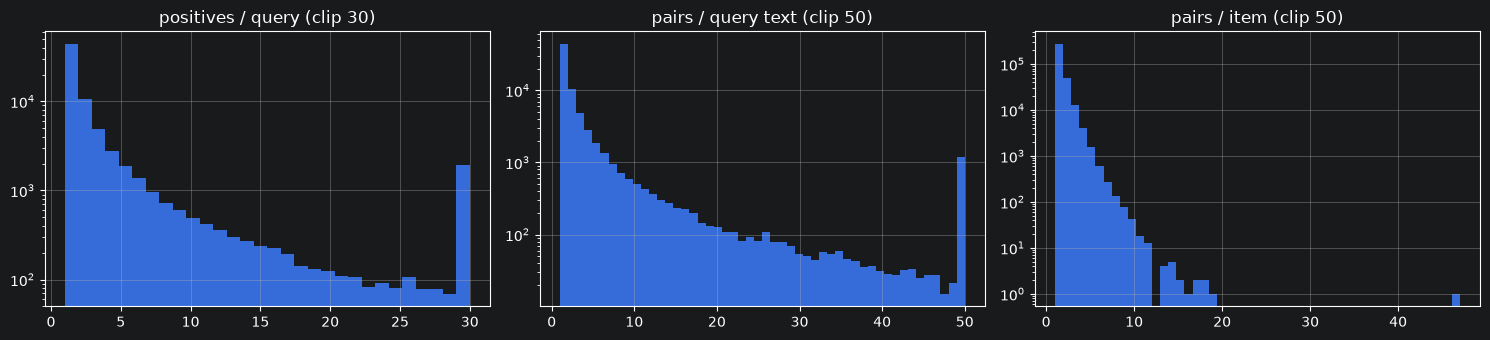


=== 12. Числовые item-признаки: доля NaN (строки с NaN не удаляются) ===


,nan_share
item_rating_reviews_count,0.046
item_rating,0.067
item_price,0.070


In [8]:
print("=== 1. Размеры ===")
print(f"train строк: {len(train):,} | уникальных нормализ. query: {pairs.qtext.nunique():,} | "
      f"уникальных items: {len(train_items):,} | уникальных пар: {len(pairs):,}")
print(f"benchmark queries: {len(bq):,} (уникальных текстов {bqn.qtext.nunique():,}) | benchmark items: {len(pool_items):,}")

print("\n=== 2. Positive-объявлений на запрос (unit) ===")
ppq = pairs.groupby("unit").size()
print(ppq.describe(percentiles=[.5, .75, .9, .99]).round(2).to_string())
print(f"доля запросов с 1 positive: {(ppq==1).mean():.3f}")

print("\n=== 3. Повторяемость запросов (строк train на текст) ===")
rows_per_q = pairs.qtext.value_counts()
print(f"текстов с 1 строкой: {(rows_per_q==1).mean():.3f}; доля строк от топ-1% текстов: {rows_per_q.head(max(1,len(rows_per_q)//100)).sum()/rows_per_q.sum():.3f}")
display(rows_per_q.head(15).to_frame("pairs"))

print("\n=== 4. Популярность items ===")
pop = pairs.titem.value_counts()
print(f"items встречающихся 1 раз: {(pop==1).mean():.3f}; макс. пар на item: {pop.max()}; доля пар от топ-1% items: {pop.head(max(1,len(pop)//100)).sum()/pop.sum():.3f}")

print("\n=== 5. Overlap train <-> benchmark ===")
tr_txt = set(pairs.qtext)
print(f"benchmark query (текст) есть в train: unique {bqn.qtext.drop_duplicates().isin(tr_txt).mean():.3f} | по строкам {bqn.qtext.isin(tr_txt).mean():.3f}")
id_ov = train_items.item_id.isin(set(pool_items.item_id)).mean()
print(f"доля train-items, присутствующих в benchmark_items (по id): {id_ov:.3f}  <- если ~0, history-по-id не работает, останутся текстовые сигналы (sim_text, bm25_qe)")
if C["q_loc"]: print(f"benchmark location есть в train: {bqn.qloc.isin(set(pairs.qloc)).mean():.3f}")
if C["q_cat"]: print(f"benchmark search_category есть в train: {bqn.qcat.isin(set(pairs.qcat)).mean():.3f}")

print("\n=== 6. Категории ===")
pi_cat = train_items.cat.values[pairs.titem.values]; pi_mic = train_items.micro.values[pairs.titem.values]
print(f"search_category: {pairs.qcat.nunique()} | item_category: {train_items.cat.nunique()} | item_microcat: {train_items.micro.nunique()}")
ct = pd.crosstab(pairs.qcat, pi_cat)
share_top = (ct.max(1)/ct.sum(1))
print("доля пар в топ-1 item_category для каждой search_category (взвешенно): %.3f" % ((ct.max(1)).sum()/ct.values.sum()))
display(ct.sum(1).sort_values(ascending=False).head(10).to_frame("pairs").assign(top1_share=share_top.round(3)))
print("item_category на search_category (медиана):", int((ct>0).sum(1).median()))
cm = pd.crosstab(pairs.qcat, pi_mic)
print("item_microcat на search_category (медиана):", int((cm>0).sum(1).median()))

print("\n=== 7. Локации ===")
same_loc = (pairs.qloc.values == train_items["loc"].values[pairs.titem.values]) & (pairs.qloc.values != "nan")
print(f"доля пар, где search_location == item_location: {same_loc.mean():.3f}")

print("\n=== 8. Длины текстов ===")
ln = pd.DataFrame({"query_tok": pairs.qtext.str.split().map(len).describe(),
                   "title_tok": train_items.t_tokens.map(len).describe(),
                   "desc_chars": train_items.d.str.len().describe(),
                   "params_tok": train_items.p.str.split().map(len).describe()}).round(1)
display(ln)
print("пустые: title %.3f | desc %.3f | params %.3f" % ((train_items.t=="").mean(), (train_items.d=="").mean(), (train_items.p=="").mean()))

print("\n=== 9. Дубликаты ===")
print(f"дубли title среди уникальных items: {train_items.t.duplicated().mean():.3f} | дубли title+desc: {(train_items.t+'|'+train_items.d).duplicated().mean():.3f}")

print("\n=== 10. Примеры запросов и positive-объявлений ===")
rng = np.random.default_rng(SEED)
for u in rng.choice(pairs.unit.unique(), size=min(5, pairs.unit.nunique()), replace=False):
    s = pairs[pairs.unit == u]
    print(f"\nQUERY: {u!r}  | cat={s.qcat.iloc[0]} loc={s.qloc.iloc[0]} params={s.qparams.iloc[0][:80]!r}")
    for j in s.titem.values[:4]: print("   +", train_items.t.iloc[j][:90], "| cat", train_items.cat.iloc[j])

print("\n=== 11. Параметры фильтров (для парсинга key-value) ===")
if C["q_params"]:
    display(pairs.qparams.value_counts().head(10).to_frame("count"))
display(train_items.p[train_items.p != ""].sample(min(5, len(train_items)), random_state=SEED).to_frame())

fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
ppq.clip(upper=30).hist(bins=30, ax=ax[0]); ax[0].set_title("positives / query (clip 30)"); ax[0].set_yscale("log")
rows_per_q.clip(upper=50).hist(bins=50, ax=ax[1]); ax[1].set_title("pairs / query text (clip 50)"); ax[1].set_yscale("log")
pop.clip(upper=50).hist(bins=50, ax=ax[2]); ax[2].set_title("pairs / item (clip 50)"); ax[2].set_yscale("log")
plt.tight_layout(); plt.show()

print("\n=== 12. Числовые item-признаки: доля NaN (строки с NaN не удаляются) ===")
if NUM_COLS: display(train_items[NUM_COLS].isna().mean().round(3).to_frame("nan_share"))


## 3. Split для оффлайн-оценки

`H` - history (из него строится все, что «знает» retrieval), `R` - запросы для обучения реранкера, `V` - валидация.
Запросы `R` и `V` в history **не попадают**, поэтому это честная симуляция benchmark. Если EDA показал сильный overlap train↔benchmark по тексту запроса, поставь `SPLIT_BY="group"`.

In [9]:
units = pairs.unit.unique()
rng = np.random.default_rng(SEED); rng.shuffle(units)
n_v = min(N_VAL_QUERIES, max(1, int(.1*len(units)))); n_r = min(N_RANK_QUERIES, max(1, int(.2*len(units))))
V_units, R_units, H_units = set(units[:n_v]), set(units[n_v:n_v+n_r]), set(units[n_v+n_r:])
pairs_H = pairs[pairs.unit.isin(H_units)].reset_index(drop=True)

def make_queries(ps):
    g = ps.groupby("unit", sort=False)
    qs = g[["qtext", "qcat", "qloc", "qparams", "qsort", "qlat", "qlon"]].first().reset_index()
    qs["pos"] = qs.unit.map(g.titem.agg(set))
    qs["qid"] = np.arange(len(qs))
    return qs

qs_R = make_queries(pairs[pairs.unit.isin(R_units)]); qs_V = make_queries(pairs[pairs.unit.isin(V_units)])
print(f"H pairs {len(pairs_H):,} | R queries {len(qs_R):,} | V queries {len(qs_V):,}")
print("доля V-текстов, встречающихся в H (exact leak):", qs_V.qtext.isin(set(pairs_H.qtext)).mean().round(3))

H pairs 431,291 | R queries 2,000 | V queries 800
доля V-текстов, встречающихся в H (exact leak): 0.0


## 3.1 Метрики и реестр результатов

Все модели (бейзлайны, отдельные retrievers, RRF, реранкер) оцениваются **одной и той же функцией** на валидации `V` - это часть train, которой нет ни в history, ни в обучении реранкера. Результаты копятся в `RESULTS`, итоговая таблица - в конце ноутбука.

* `Recall@K` - доля positive-объявлений запроса, попавших в топ-K (среднее по запросам)
* `Hit@50` - доля запросов, где в топ-50 есть хотя бы один positive
* `MRR@50`, `nDCG@50` - учитывают позицию positive в списке

In [10]:
ALL_KS = tuple(sorted(set(EVAL_KS) | set(METRIC_KS)))
RESULTS = {}      # имя модели -> {"stage": ..., метрики}

def eval_lists(lists, pos_sets, ks=ALL_KS, k_rank=50):
    """lists[i] - упорядоченный массив индексов объявлений для запроса i, pos_sets[i] - множество positive"""
    n = len(pos_sets); kmax = max(max(ks), k_rank)
    R = {k: np.zeros(n) for k in ks}; hit = np.zeros(n); mrr = np.zeros(n); ndcg = np.zeros(n)
    disc = 1.0 / np.log2(np.arange(2, k_rank + 2))
    for i, (l, p) in enumerate(zip(lists, pos_sets)):
        if not len(p): continue
        top = np.asarray(l)[:kmax]; isp = np.fromiter((x in p for x in top), bool, count=len(top))
        for k in ks: R[k][i] = isp[:k].sum() / len(p)
        h = isp[:k_rank]; hit[i] = h.any()
        w = np.flatnonzero(h); mrr[i] = 1.0 / (w[0] + 1) if len(w) else 0.0
        ndcg[i] = (h * disc[:len(h)]).sum() / disc[:min(len(p), k_rank)].sum()
    out = {f"Recall@{k}": R[k].mean() for k in ks}
    out.update({f"Hit@{k_rank}": hit.mean(), f"MRR@{k_rank}": mrr.mean(), f"nDCG@{k_rank}": ndcg.mean()})
    return out

def register(name, stage, lists, qs):
    m = eval_lists(lists, qs.pos.tolist()); RESULTS[name] = {"stage": stage, **m}; return m

def lists_from_scores(cand, score, n_q):
    """cand (qid, item) + score -> список упорядоченных массивов на запрос (qid == позиция в qs)"""
    d = cand[["qid", "item"]].assign(s=score).sort_values(["qid", "s"], ascending=[True, False])
    q, it = d.qid.values, d.item.values; out = [np.empty(0, dtype=np.int64) for _ in range(n_q)]
    if len(q):
        cuts = np.flatnonzero(np.diff(q)) + 1
        for k, part in zip(q[np.r_[0, cuts]], np.split(it, cuts)): out[int(k)] = part
    return out

## 4. Индексы и retrievers

* `ItemIndex` - по пулу объявлений. Строятся **только** те индексы, что нужны выбранным retrievers (см. `NEED`): BM25 (title / title+params / полный текст), word TF-IDF, char TF-IDF.
* `HistIndex` - по history: exact query→items, похожие запросы→items, центроид текстов выбранных items (`sim_text`, работает даже если id items в benchmark не пересекаются с train), query expansion, таблицы `search_category→item_category/microcat`, популярность.
* Категория/локация/расстояние считаются как мягкие признаки **только для кандидатов** (а не для всего пула), поэтому это почти бесплатно.

In [11]:
TOKEN = r"(?u)\b\w+\b"

def binarize(Q): Q = Q.tocsr(); Q.data[:] = 1; return Q

def fit_tfidf(docs, **kw):
    v = TfidfVectorizer(dtype=np.float32, sublinear_tf=True, **kw)
    try: X = v.fit_transform(docs)
    except ValueError:                       # слишком маленький корпус для max_df/min_df
        kw = {k: x for k, x in kw.items() if k not in ("max_df", "min_df")}
        v = TfidfVectorizer(dtype=np.float32, sublinear_tf=True, **kw); X = v.fit_transform(docs)
    return v, X

class BM25:
    def __init__(self, docs, k1=1.2, b=0.75):
        self.cv = CountVectorizer(token_pattern=TOKEN, dtype=np.float32)
        X = self.cv.fit_transform(docs).tocsr()
        N = X.shape[0]; df = np.bincount(X.indices, minlength=X.shape[1])
        idf = np.log(1 + (N - df + .5) / (df + .5)).astype(np.float32)
        dl = np.asarray(X.sum(1)).ravel(); avg = max(dl.mean(), 1e-6)
        X = X.tocoo()
        data = X.data * (k1 + 1) / (X.data + k1 * (1 - b + b * dl[X.row] / avg)) * idf[X.col]
        self.W = sp.csr_matrix((data.astype(np.float32), (X.row, X.col)), shape=X.shape).T.tocsr()  # vocab x docs
    def score(self, texts, extra=None, w=0.5):
        Q = binarize(self.cv.transform(texts))
        if extra is not None: Q = Q + w * binarize(self.cv.transform(extra))
        return Q @ self.W

class ItemIndex:
    def __init__(self, items):
        t0 = time.time(); self.items = items; self.n = len(items)
        stages = [k for k in ("bm25_title", "bm25_tp", "bm25_full") if k in NEED] + (["tf_word"] if {"tf_word", "sim_text"} & NEED else []) \
                 + (["tf_char"] if "tf_char" in NEED else []) + ["overlap/geo"]
        pb = tqdm(total=len(stages), desc="ItemIndex", leave=False)
        for k in ("bm25_title", "bm25_tp", "bm25_full"):
            if k in NEED:
                pb.set_description(f"ItemIndex: {k}"); setattr(self, k, BM25(items[{"bm25_title": "t", "bm25_tp": "tp", "bm25_full": "full"}[k]])); pb.update(1)
        if {"tf_word", "sim_text"} & NEED:
            pb.set_description("ItemIndex: tf_word")
            self.tf_word, self.Xw = fit_tfidf(items.tp, token_pattern=TOKEN, ngram_range=(1, 2) if not FAST else (1, 1), min_df=WORD_MIN_DF); pb.update(1)
        if "tf_char" in NEED:
            pb.set_description("ItemIndex: tf_char (самый долгий)")
            self.tf_char, self.Xc = fit_tfidf(items.tp, analyzer="char_wb", ngram_range=CHAR_NGRAM, min_df=CHAR_MIN_DF, max_df=CHAR_MAX_DF, max_features=CHAR_MAX_FEATURES); pb.update(1)
        pb.set_description("ItemIndex: overlap/geo")
        # быстрые бинарные матрицы для признаков "доля токенов запроса в title/title+params/params" (считаются только для кандидатов)
        self.cv_ov = CountVectorizer(token_pattern=TOKEN, dtype=np.float32).fit(items.tp)
        self.Bt, self.Btp, self.Bp = (binarize(self.cv_ov.transform(x)) for x in (items.t, items.tp, items.p))
        lc = {v: i for i, v in enumerate(pd.unique(items["loc"])) if v != "nan"}
        self.loc_code = np.array([lc.get(v, -1) for v in items["loc"]]); self.loc_map = lc
        self.has_geo = items.lat.notna().any() and items.lon.notna().any()
        self.lat_r = np.radians(items.lat.values.astype(np.float32)); self.lon_r = np.radians(items.lon.values.astype(np.float32))
        self.notna = {c: items[c].notna().values for c in NUM_COLS}   # для подрезки кандидатов по сортировке (раздел 6)
        pb.update(1); pb.close()
        print(f"ItemIndex: {self.n:,} items ({time.time()-t0:.0f}s) | индексы: {sorted(NEED)}")

class CondTable:
    # P(item_value | query_value), считается по history-парам
    def __init__(self, qv, iv):
        ct = pd.crosstab(np.asarray(qv), np.asarray(iv))
        M = ct.values.astype(np.float32); M = M / np.maximum(M.sum(1, keepdims=True), 1)
        self.M = np.pad(M, ((0, 1), (0, 1))); self.nq, self.ni = M.shape
        self.qmap = {v: i for i, v in enumerate(ct.index)}; self.imap = {v: i for i, v in enumerate(ct.columns)}
    def item_cols(self, ivals): return np.array([self.imap.get(v, self.ni) for v in ivals])
    def matrix(self, qvals, icols):
        rows = np.array([self.qmap.get(v, self.nq) for v in qvals]); return self.M[rows][:, icols]
    def vec(self, qval, icols_cand): return self.M[self.qmap.get(qval, self.nq), icols_cand]

class HistIndex:
    def __init__(self, ph, hist_items, ix):
        t0 = time.time(); self.hist_items = hist_items; self.ix = ix
        pb = tqdm(total=4, desc="HistIndex", leave=False)
        texts, inv = np.unique(ph.qtext.values, return_inverse=True)
        self.texts = texts; self.t2r = {t: i for i, t in enumerate(texts)}; nt = len(texts)
        self.TQ = sp.csr_matrix((np.ones(len(ph), np.float32), (inv, ph.titem.values)), shape=(nt, len(hist_items)))  # train-space
        self.TQ.sum_duplicates()
        # map train-item -> pool-item (по id)
        pm = pd.Series(np.arange(ix.n), index=ix.items.item_id)
        m = hist_items.item_id.map(pm); ok = m.notna().values
        self.M = sp.csr_matrix((np.ones(ok.sum(), np.float32), (np.where(ok)[0], m[ok].astype(int).values)), shape=(len(hist_items), ix.n))
        self.TQ_pool = (self.TQ @ self.M).tocsr()
        self.pop = np.log1p(np.asarray(self.M.T @ np.asarray(self.TQ.sum(0)).ravel()).ravel())
        pb.update(1)
        # запрос-запрос (для sim_hist / sim_text / bm25_qe)
        if {"sim_hist", "sim_text", "bm25_qe"} & NEED:
            self.qv, self.HQ = fit_tfidf(texts, analyzer="char_wb", ngram_range=QCHAR_NGRAM, min_df=2, max_df=QCHAR_MAX_DF)
        pb.update(1)
        if "sim_text" in NEED:   # центроиды текстов выбранных items (в пространстве word-tfidf пула)
            Xh = ix.Xw if hist_items is ix.items else ix.tf_word.transform(hist_items.tp)
            self.QC = normalize(self.TQ @ Xh)
        if "bm25_qe" in NEED:    # для query expansion
            self.tokens = hist_items.t_tokens.values
            df = Counter(tok for toks in self.tokens for tok in set(toks)); N = len(self.tokens)
            self.tidf = {k: math.log(1 + N / v) for k, v in df.items()}
        pb.update(1)
        # категории
        self.cat_tab = CondTable(ph.qcat.values, hist_items.cat.values[ph.titem.values])
        self.mic_tab = CondTable(ph.qcat.values, hist_items.micro.values[ph.titem.values])
        pb.update(1); pb.close()
        print(f"HistIndex: {nt:,} unique query texts, id-overlap items {ok.mean():.3f} ({time.time()-t0:.0f}s)")

    def sim_weights(self, texts, k=SIM_TOPK):
        S = (self.qv.transform(texts) @ self.HQ.T).tocsr(); R, Cc, V = [], [], []
        for r in range(S.shape[0]):
            s, e = S.indptr[r], S.indptr[r+1]; d, c = S.data[s:e], S.indices[s:e]
            if len(d) > k: top = np.argpartition(-d, k)[:k]; d, c = d[top], c[top]
            R.append(np.full(len(d), r)); Cc.append(c); V.append(d ** 2)
        return sp.csr_matrix((np.concatenate(V), (np.concatenate(R), np.concatenate(Cc))), shape=(len(texts), len(self.texts)))

    def exact(self, texts):
        ok = [(i, self.t2r[t]) for i, t in enumerate(texts) if t in self.t2r]
        if not ok: return np.zeros((len(texts), self.ix.n), np.float32)
        Sel = sp.csr_matrix((np.ones(len(ok), np.float32), ([i for i, _ in ok], [r for _, r in ok])), shape=(len(texts), len(self.texts)))
        return (Sel @ self.TQ_pool).toarray()

    def expansion_terms(self, W, texts, top_items=5, n_terms=6):
        R = (W @ self.TQ).tocsr(); out = []
        for r, t in enumerate(texts):
            s, e = R.indptr[r], R.indptr[r+1]; d, c = R.data[s:e], R.indices[s:e]
            if len(d) == 0: out.append(""); continue
            qs = set(t.split()); cnt = Counter()
            for j in np.argsort(-d)[:top_items]:
                for tok in set(self.tokens[c[j]]):
                    if len(tok) >= 3 and tok not in qs: cnt[tok] += d[j] * self.tidf.get(tok, 1.0)
            out.append(" ".join(w for w, _ in cnt.most_common(n_terms)))
        return out

def rownorm(x): return x / np.maximum(x.max(1, keepdims=True), 1e-9)

def haversine(lat1, lon1, lat2, lon2):
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

def compute_scores(qb, ix, hist, cat_cols):
    # Плотные матрицы (batch x n_items) только для нужных скореров
    texts = qb.qtext.tolist(); S = {}
    for k in ("bm25_title", "bm25_tp", "bm25_full"):
        if k in NEED: S[k] = getattr(ix, k).score(texts).toarray()
    if "tf_word" in NEED: S["tf_word"] = (ix.tf_word.transform(texts) @ ix.Xw.T).toarray()
    if "tf_char" in NEED: S["tf_char"] = (ix.tf_char.transform(texts) @ ix.Xc.T).toarray()
    if "exact_hist" in NEED: S["exact_hist"] = rownorm(hist.exact(texts))
    if {"sim_hist", "sim_text", "bm25_qe"} & NEED:
        W = hist.sim_weights(texts)
        if "sim_hist" in NEED: S["sim_hist"] = rownorm((W @ hist.TQ_pool).toarray())
        if "sim_text" in NEED: S["sim_text"] = (normalize(W @ hist.QC) @ ix.Xw.T).toarray()
        if "bm25_qe" in NEED:  S["bm25_qe"] = ix.bm25_full.score(texts, extra=hist.expansion_terms(W, texts)).toarray()
    if {"bm25_cat", "bm25_loc"} & set(RETRIEVERS):
        bn = rownorm(S["bm25_full"])
        if "bm25_cat" in RETRIEVERS: S["bm25_cat"] = bn * (0.2 + rownorm(hist.cat_tab.matrix(qb.qcat.values, cat_cols)))
        if "bm25_loc" in RETRIEVERS:
            qc = np.array([ix.loc_map.get(v, -2) for v in qb.qloc.values]); S["bm25_loc"] = bn * (0.5 + 0.5 * (qc[:, None] == ix.loc_code[None, :]))
    return S

def batch_top(M, k):
    k = min(k, M.shape[1] - 1)
    idx = np.argpartition(-M, k, axis=1)[:, :k]; vals = np.take_along_axis(M, idx, 1)
    o = np.argsort(-vals, 1); return np.take_along_axis(idx, o, 1), np.take_along_axis(vals, o, 1)

def rank_in(ranked_idx, cand, default):
    if len(ranked_idx) == 0: return np.full(len(cand), default, np.float32)
    srt = np.argsort(ranked_idx); pos = np.searchsorted(ranked_idx, cand, sorter=srt).clip(0, len(ranked_idx) - 1)
    hit = ranked_idx[srt[pos]] == cand
    return np.where(hit, srt[pos] + 1, default).astype(np.float32)

def generate(qs, ix, hist, verbose=True):
    # Для каждого запроса: union кандидатов из всех retrievers + признаки. Возвращает (cand_df, ranked: name -> list of idx-arrays)
    items = ix.items; cat_cols = hist.cat_tab.item_cols(items.cat.values); mic_cols = hist.mic_tab.item_cols(items.micro.values)
    ranked = {n: [] for n in RETRIEVERS}; parts = []; t0 = time.time(); has_pos = "pos" in qs.columns; nrows = 0
    pbar = tqdm(range(0, len(qs), BATCH), desc="generate", disable=not verbose)
    for b0 in pbar:
        qb = qs.iloc[b0:b0 + BATCH]; S = compute_scores(qb, ix, hist, cat_cols)
        Qt = binarize(ix.cv_ov.transform(qb.qtext.tolist())); Qp = binarize(ix.cv_ov.transform(qb.qparams.tolist()))
        tops = {}
        for n, (key, K) in RETRIEVERS.items():
            idx, val = batch_top(S[key], RANK_DEPTH)
            tops[n] = [idx[r][val[r] > 0] for r in range(len(qb))]; ranked[n].extend(tops[n])
        for r, (_, q) in enumerate(qb.iterrows()):
            cand = np.unique(np.concatenate([tops[n][r][:RETRIEVERS[n][1]] for n in RETRIEVERS]))
            if PRUNE_BY_SORT and RULE_COLS:      # подрезка: под данную сортировку таргет (по train) всегда имеет непустые эти поля
                for c in RULE_COLS.get(q.qsort, ()): cand = cand[ix.notna[c][cand]]
            if len(cand) == 0: continue
            L = len(cand); f = {"qid": np.full(L, q.qid), "item": cand}
            f["label"] = np.isin(cand, np.fromiter(q.pos, int)).astype(np.int8) if has_pos else np.zeros(L, np.int8)
            for k, v in S.items(): f["s_" + k] = v[r, cand]
            rrf = np.zeros(L, np.float32); nret = np.zeros(L, np.float32)
            for n in RETRIEVERS:
                rk = rank_in(tops[n][r], cand, RANK_DEPTH + 1); f["r_" + n] = rk
                rrf += np.where(rk <= RANK_DEPTH, 1.0 / (RRF_K + rk), 0); nret += rk <= RETRIEVERS[n][1]
            f["rrf"] = rrf; f["n_ret"] = nret
            # категория / локация / расстояние - только для кандидатов
            f["catp"] = hist.cat_tab.vec(q.qcat, cat_cols[cand]); f["micp"] = hist.mic_tab.vec(q.qcat, mic_cols[cand])
            f["same_loc"] = (ix.loc_code[cand] == ix.loc_map.get(q.qloc, -2)).astype(np.float32)
            f["dist"] = haversine(np.radians(q.qlat), np.radians(q.qlon), ix.lat_r[cand], ix.lon_r[cand]).astype(np.float32) if (ix.has_geo and pd.notna(q.qlat) and pd.notna(q.qlon)) else np.full(L, np.nan, np.float32)
            # текстовые признаки (разреженные матрицы, только для кандидатов)
            nq = max(len(set(q.qtext.split())), 1); npq = len(set(q.qparams.split()))
            f["q_len"] = np.full(L, nq, np.float32); f["t_len"] = items.t_len.values[cand]
            f["q_in_title"] = np.asarray((ix.Bt[cand] @ Qt[r].T).todense()).ravel() / nq
            f["q_in_tp"] = np.asarray((ix.Btp[cand] @ Qt[r].T).todense()).ravel() / nq
            f["param_ovl"] = np.asarray((ix.Bp[cand] @ Qp[r].T).todense()).ravel() / npq if npq else np.zeros(L, np.float32)
            f["pop"] = hist.pop[cand]
            f["qsort_code"] = np.full(L, SORT_CODE.get(q.qsort, -1), np.float32)
            for c in NUM_COLS: f["num_" + c] = items[c].values[cand]
            parts.append(pd.DataFrame(f)); nrows += L
        pbar.set_postfix(cand_per_q=f"{nrows / (b0 + len(qb)):.0f}")
    pbar.close()
    out = pd.concat(parts, ignore_index=True)
    # ранг числового признака среди кандидатов ЭТОГО запроса: позволяет модели выучить "сортировка по цене/рейтингу/расстоянию"; NaN остается NaN
    for c in [("num_" + x) for x in NUM_COLS] + ["dist"]:
        out["rk_" + c.replace("num_", "")] = out.groupby("qid")[c].rank(pct=True).astype(np.float32)
    return out, ranked

## 5. Бейзлайны (самые простые и быстрые)

Считаем до тяжелого пайплайна, чтобы понимать нижнюю планку. Все бейзлайны используют только history `H` и оцениваются на `V`; в каждом отдается топ-`RANK_DEPTH` объявлений.

| бейзлайн | что делает |
|---|---|
| `random` | случайные объявления (совсем нижняя планка) |
| `popular (global)` | одни и те же самые частые объявления для всех |
| `popular (search_category)` | самые частые в истории для той же категории поиска |
| `popular (category+location)` | то же для пары категория+локация, с откатом на категорию и глобальный топ |
| `exact query -> popular` | что выбирали по точно такому же тексту запроса, иначе откат на цепочку выше |
| `BM25 title` | классический BM25 запроса по заголовку |
| `TF-IDF word (title+params)` | косинус слов запроса и title+params |

In [12]:
KMAX = RANK_DEPTH
nV, N_ITEMS = len(qs_V), len(train_items)
EMPTY = np.empty(0, dtype=np.int64)
_rng = np.random.default_rng(SEED)

def head_unique(arrs, k=KMAX):
    """склеиваем списки (приоритет слева направо), убираем повторы, берем первые k"""
    arrs = [a for a in arrs if len(a)]
    if not arrs: return EMPTY
    a = np.concatenate(arrs); _, first = np.unique(a, return_index=True)
    return a[np.sort(first)][:k]

def top_lists(keys, df):
    """{(значения keys): массив titem по убыванию частоты (число разных запросов)}"""
    if len(df) == 0: return {}
    t = df.groupby(keys + ["titem"]).size().rename("n").reset_index()
    t = t.sort_values(keys + ["n"], ascending=[True] * len(keys) + [False]).groupby(keys, sort=False).head(KMAX)
    return {(k if isinstance(k, tuple) else (k,)): g.titem.values for k, g in t.groupby(keys, sort=False)}

def text_baseline(score_fn, texts, desc):
    out = []
    for b0 in tqdm(range(0, len(texts), BATCH), desc=desc, leave=False):
        idx, val = batch_top(score_fn(texts[b0:b0 + BATCH]), KMAX)
        out.extend(idx[r][val[r] > 0] for r in range(len(idx)))
    return out

BASELINES = [
    "random", "popular (global)", "popular (search_category)", "popular (category+location)",
    "exact query -> popular", "BM25 title", "TF-IDF word (title+params)"]
t_all = time.time()
for name in tqdm(BASELINES, desc="baselines"):
    t0 = time.time()
    if name == "random":
        lists = [_rng.choice(N_ITEMS, min(KMAX, N_ITEMS), replace=False) for _ in range(nV)]
    elif name == "popular (global)":
        POP_G = pairs_H.titem.value_counts().index.values[:KMAX]; lists = [POP_G] * nV
    elif name == "popular (search_category)":
        POP_CAT = top_lists(["qcat"], pairs_H)
        lists = [head_unique([POP_CAT.get((c,), EMPTY), POP_G]) for c in qs_V.qcat]
    elif name == "popular (category+location)":
        POP_CL = top_lists(["qcat", "qloc"], pairs_H)
        lists = [head_unique([POP_CL.get((c, l), EMPTY), POP_CAT.get((c,), EMPTY), POP_G]) for c, l in zip(qs_V.qcat, qs_V.qloc)]
    elif name == "exact query -> popular":
        EXACT = top_lists(["qtext"], pairs_H[pairs_H.qtext.isin(set(qs_V.qtext))])
        lists = [head_unique([EXACT.get((t,), EMPTY), POP_CL.get((c, l), EMPTY), POP_CAT.get((c,), EMPTY), POP_G]) for t, c, l in zip(qs_V.qtext, qs_V.qcat, qs_V.qloc)]
    elif name == "BM25 title":
        _bm = BM25(train_items.t); lists = text_baseline(lambda tx: _bm.score(tx).toarray(), qs_V.qtext.tolist(), "BM25 title")
    elif name == "TF-IDF word (title+params)":
        _vw, _Xw = fit_tfidf(train_items.tp, token_pattern=TOKEN, min_df=WORD_MIN_DF)
        lists = text_baseline(lambda tx: (_vw.transform(tx) @ _Xw.T).toarray(), qs_V.qtext.tolist(), "TF-IDF word")
    m = register("baseline: " + name, "baseline", lists, qs_V)
    print(f"{name:34s} Recall@50={m['Recall@50']:.4f}  nDCG@50={m['nDCG@50']:.4f}  ({time.time()-t0:.1f}s)")
print(f"бейзлайны посчитаны за {time.time()-t_all:.0f}s")

_b = pd.DataFrame(RESULTS).T; _b = _b[_b.stage == "baseline"].drop(columns="stage").astype(float)
display(_b[[c for c in ("Recall@10", "Recall@50", "Recall@200", "Hit@50", "MRR@50", "nDCG@50") if c in _b.columns]].round(4))
print("доля V-текстов, которые есть в history (exact leak):", round(qs_V.qtext.isin(set(pairs_H.qtext)).mean(), 3),
      "-> при SPLIT_BY='text' это 0, поэтому 'exact query' откатывается на popularity: честная симуляция benchmark")

baselines:   0%|          | 0/7 [00:00<?, ?it/s]

random                             Recall@50=0.0013  nDCG@50=0.0003  (0.1s)


baselines:  29%|██▊       | 2/7 [00:00<00:00, 12.56it/s]

popular (global)                   Recall@50=0.0018  nDCG@50=0.0015  (0.1s)
popular (search_category)          Recall@50=0.0018  nDCG@50=0.0015  (0.3s)


baselines:  71%|███████▏  | 5/7 [00:01<00:00,  4.37it/s]

...

BM25 title                         Recall@50=0.1842  nDCG@50=0.1097  (4.6s)



baselines: 100%|██████████| 7/7 [01:01<00:00,  8.81s/it]    

TF-IDF word (title+params)         Recall@50=0.1824  nDCG@50=0.0937  (55.9s)
бейзлайны посчитаны за 62s


,Recall@10,Recall@50,Recall@200,Hit@50,MRR@50,nDCG@50
baseline: random,0.0000,0.0013,0.0018,0.0025,0.0001,0.0003
baseline: popular (global),0.0013,0.0018,0.0036,0.0050,0.0020,0.0015
baseline: popular (search_category),0.0013,0.0018,0.0036,0.0050,0.0020,0.0015
baseline: popular (category+location),0.0105,0.0240,0.0624,0.0338,0.0068,0.0099
baseline: exact query -> popular,0.0105,0.0240,0.0624,0.0338,0.0068,0.0099
baseline: BM25 title,0.1050,0.1842,0.2693,0.3050,0.1200,0.1097
baseline: TF-IDF word (title+params),0.0909,0.1824,0.2975,0.2912,0.0889,0.0937


доля V-текстов, которые есть в history (exact leak): 0.0 -> при SPLIT_BY='text' это 0, поэтому 'exact query' откатывается на popularity: честная симуляция benchmark


## 6. Сортировка в `search_infm_params_text`: всегда ли таргет ей соответствует?

Что проверяем:
1. В какой доле запросов в параметрах поиска есть сортировка и какие бывают значения (regex `SORT_KEY_RX` в конфиге - сверься с выводом и поправь при необходимости).
2. Для каждого значения сортировки и каждой числовой колонки объявления (рейтинг, цена, ...): **доля positive с NaN** - если она строго 0, а в пуле NaN много, то кандидатов с NaN можно срезать: таргет им не бывает.
3. **Медианный процентиль** значения таргета среди объявлений его категории. Сравниваем с строкой `__no_sort__`: если при сортировке «по цене» медиана заметно ниже (или выше для «по убыванию»), таргет следует сортировке, и это видно реранкеру через признаки `qsort_code` и `rk_*` (ранг признака среди кандидатов запроса).

Правила подрезки (`RULE_COLS`) создаются автоматически и **только там, где таргет соответствует всегда** (доля нарушений `<= PRUNE_TOL`, по умолчанию 0, при числе пар `>= PRUNE_MIN_Q`). Они применяются в `generate` одинаково при обучении реранкера, валидации и инференсе. Отключить: `PRUNE_BY_SORT = False`. Расстояние (`dist`) на соответствие сортировке здесь не проверяется - только через признаки `dist` и `rk_dist`.

In [13]:
SORT_CODE = {v: i for i, v in enumerate(sorted(pairs.qsort.unique()))}   # код сортировки -> признак реранкера
RULE_COLS = {}

if not C.get("q_params"):
    print("в train нет колонки search_infm_params_text - раздел пропущен")
else:
    rs = train[C["q_params"]].dropna().astype(str)
    has = rs.str.contains(SORT_KEY_RX, case=False, regex=True)
    print(f"строк train с непустыми params: {len(rs):,} | с ключом сортировки: {int(has.sum()):,} ({100 * has.mean():.1f}%)")
    if has.sum() == 0:
        print("сортировка не найдена: проверь SORT_KEY_RX в конфиге по реальному формату params")
    else:
        print("примеры сырых значений с сортировкой (проверь, что regex достает именно значение сортировки):")
        display(rs[has].drop_duplicates().head(8).to_frame("raw params"))
    sv = pairs.qsort.value_counts()
    display(sv.head(15).to_frame("pairs"))

    keep = [s for s in sv.index if s != NO_SORT and sv[s] >= 30][:12]
    if keep and NUM_COLS:
        ti = pairs.titem.values
        pos_v = {c: train_items[c].values[ti] for c in NUM_COLS}
        pct = {c: train_items.groupby("cat")[c].rank(pct=True).values[ti] for c in tqdm(NUM_COLS, desc="percentiles", leave=False)}
        groups = [NO_SORT] + keep
        nan_t = pd.DataFrame(index=groups, columns=NUM_COLS, dtype=float); med_t = nan_t.copy()
        for s in groups:
            m = pairs.qsort.values == s
            for c in NUM_COLS:
                nan_t.loc[s, c] = np.isnan(pos_v[c][m]).mean()
                p = pct[c][m]; med_t.loc[s, c] = np.nanmedian(p) if np.isfinite(p).any() else np.nan
        pool_nan = train_items[NUM_COLS].isna().mean()
        n_col = pd.Series({s: int((pairs.qsort.values == s).sum()) for s in groups}, name="n_pairs")
        print("\nДоля NaN у positive-объявлений по значению сортировки, % (нижняя строка - доля NaN во всем пуле объявлений):")
        tbl = pd.concat([n_col.to_frame(), (100 * nan_t).round(2)], axis=1)
        tbl.loc["ALL ITEMS (pool)"] = [len(train_items)] + list((100 * pool_nan).round(2).values)
        display(tbl)
        print("Медианный процентиль значения таргета среди объявлений его категории (0.5 = как у случайного; сравни с __no_sort__):")
        display(pd.concat([n_col.to_frame(), med_t.round(3)], axis=1))

        for s in keep:
            if sv[s] < PRUNE_MIN_Q: continue
            cols = [c for c in NUM_COLS if nan_t.loc[s, c] <= PRUNE_TOL and pool_nan[c] >= 0.02]
            if cols: RULE_COLS[s] = cols
        if RULE_COLS:
            print("\nПравила подрезки (таргет всегда соответствует):")
            for s, cols in RULE_COLS.items():
                print(f"  sort={s!r}: требуем не-NaN {cols} | у positive NaN: 0 из {sv[s]:,} пар | из пула уйдет до {100 * pool_nan[cols].max():.0f}% объявлений")
        else:
            print("\nПравил подрезки нет: либо у positive NaN встречаются, либо в пуле нет заметной доли NaN, либо мало пар с сортировкой.")
    else:
        print("нет значений сортировки с >= 30 пар или нет числовых колонок - правил подрезки нет")
print("RULE_COLS:", RULE_COLS, "| PRUNE_BY_SORT =", PRUNE_BY_SORT)

строк train с непустыми params: 467,054 | с ключом сортировки: 336 (0.1%)
примеры сырых значений с сортировкой (проверь, что regex достает именно значение сортировки):


,raw params
360,"Сортировка для URL Сначала дорогие Вид услуги Автосервис, аренда Тип услуги Аренда авто"
566,"Сортировка для URL Сначала дешевые Тип услуги Дизайн, рисование Вид услуги Обучение, курсы"
1693,"Сортировка для URL Сначала дешевые Тип услуги Ресницы, брови Вид услуги Красота, здоровье"
4093,Сортировка для URL Сначала дешевые
7431,Сортировка для URL Сначала дорогие Вид услуги Фото- и видеосъёмка
10059,"Сортировка для URL Сначала дешевые Вид услуги Сад, благоустройство"
12242,"Сортировка для URL Сначала дешевые Вид услуги Обучение, курсы"
14757,"Сортировка для URL Сначала дешевые Вид услуги Автосервис, аренда Тип услуги Аренда спецтехники"


,pairs
qsort,
__no_sort__,444870
для url сначала дешевые,77
для url сначала дешевые тип услуги маник,22
для url сначала дешевые вид услуги ремон,21
для url сначала дешевые вид услуги автос,20
для url сначала дешевые вид услуги красо,19
для url сначала дешевые тип услуги ресни,15
для url сначала дешевые вид услуги обуче,14
для url сначала дешевые тип услуги услуг,12



Доля NaN у positive-объявлений по значению сортировки, % (нижняя строка - доля NaN во всем пуле объявлений):


,n_pairs,item_rating_reviews_count,item_rating,item_price
__no_sort__,444870.0,3.90,5.80,6.75
для url сначала дешевые,77.0,9.09,11.69,2.60
ALL ITEMS (pool),344825.0,4.55,6.75,6.95


Медианный процентиль значения таргета среди объявлений его категории (0.5 = как у случайного; сравни с __no_sort__):


,n_pairs,item_rating_reviews_count,item_rating,item_price
__no_sort__,444870,0.536,0.734,0.519
для url сначала дешевые,77,0.437,0.734,0.415



Правил подрезки нет: либо у positive NaN встречаются, либо в пуле нет заметной доли NaN, либо мало пар с сортировкой.
RULE_COLS: {} | PRUNE_BY_SORT = True


## 7. Оффлайн-оценка: метрики каждого retriever и union

In [14]:
t0 = time.time()
ix_val = ItemIndex(train_items)                       # пул валидации = все train-объявления
hist_H = HistIndex(pairs_H, train_items, ix_val)      # история = только H
cand_V, ranked_V = generate(qs_V, ix_val, hist_H)
print(f"generated for V in {time.time()-t0:.0f}s | candidates/query: {cand_V.groupby('qid').size().mean():.0f}")

rt_rows = {}
for n, lists in tqdm(ranked_V.items(), desc="metrics: retrievers"):
    rt_rows[n] = register("retriever: " + n, "retriever", lists, qs_V)
rt = pd.DataFrame(rt_rows).T[[f"Recall@{k}" for k in EVAL_KS]].round(4)

npos_V = qs_V.set_index("qid").pos.map(len)
union_rec = (cand_V.groupby("qid").label.sum().reindex(npos_V.index).fillna(0) / npos_V).mean()
register("fusion: RRF (без обучения)", "fusion", lists_from_scores(cand_V, cand_V.rrf.values, len(qs_V)), qs_V)
display(rt)
print(f"Union recall (потолок реранкера): {union_rec:.4f}  |  среднее число кандидатов: {cand_V.groupby('qid').size().mean():.0f}")
print("Вклад: recall union без каждого retriever (drop-one) можно посмотреть, убрав его из RETRIEVERS.")

ItemIndex: 344,825 items (650s) | индексы: ['bm25_cat', 'bm25_full', 'bm25_qe', 'exact_hist', 'sim_hist', 'sim_text', 'tf_char']


HistIndex: 70,906 unique query texts, id-overlap items 1.000 (4s)


generate: 100%|██████████| 25/25 [03:02<00:00,  7.31s/it, cand_per_q=363]


generated for V in 838s | candidates/query: 363


metrics: retrievers: 100%|██████████| 7/7 [00:00<00:00, 19.67it/s]


,Recall@10,Recall@20,Recall@50,Recall@100,Recall@200
exact_hist,0.0000,0.0000,0.0000,0.0000,0.0000
sim_hist,0.0295,0.0387,0.0573,0.0709,0.0923
sim_text,0.0250,0.0353,0.0673,0.1156,0.1583
bm25_full,0.1432,0.1852,0.2530,0.3143,0.3911
tf_char,0.1074,0.1447,0.2100,0.2678,0.3468
bm25_qe,0.1147,0.1621,0.2418,0.3264,0.4057
bm25_cat,0.1432,0.1852,0.2530,0.3143,0.3911


Union recall (потолок реранкера): 0.4841  |  среднее число кандидатов: 363
Вклад: recall union без каждого retriever (drop-one) можно посмотреть, убрав его из RETRIEVERS.


## 8. Реранкер поверх union-кандидатов

Негативы - не случайные объявления, а **hard negatives**: кандидаты, которые retrievers сочли похожими на запрос, но пользователь их не выбрал.
Тренируем на запросах `R` (они не входят в history), оцениваем на `V`. Чтобы обучение и применение видели одинаковое распределение, и там и там берем **топ-`RERANK_TOPN` кандидатов по RRF на запрос** (`cut_topn`). Используется LightGBM LambdaRank, если установлен, иначе CatBoostRanker, иначе sklearn HistGradientBoosting.

In [15]:
t0 = time.time()
cand_R, ranked_R = generate(qs_R, ix_val, hist_H)
print(f"generated for R in {time.time()-t0:.0f}s | rows {len(cand_R):,} | pos rate {cand_R.label.mean():.4f}")
FEATS = [c for c in cand_R.columns if c not in ("qid", "item", "label")]

class LGBTqdm:
    """прогресс-бар по деревьям LightGBM"""
    order = 30; before_iteration = False        # LightGBM требует эти атрибуты у кастомных callback
    def __init__(self, n): self.pb = tqdm(total=n, desc="LightGBM trees")
    def __call__(self, env): self.pb.update(1)
    def close(self): self.pb.close()

def fit_ranker(tr, feats):
    tr = tr.sort_values("qid"); grp = tr.groupby("qid", sort=False).size().values
    try:
        import lightgbm as lgb
        m = lgb.LGBMRanker(objective="lambdarank", random_state=SEED, verbose=-1, **LGB_PARAMS)
        cb = LGBTqdm(LGB_PARAMS["n_estimators"])
        try: m.fit(tr[feats], tr.label, group=grp, callbacks=[cb])
        finally: cb.close()
        return m, "lightgbm"
    except ImportError: pass
    try:
        from catboost import CatBoostRanker, Pool
        m = CatBoostRanker(loss_function="YetiRank", iterations=300 if FAST else 600, learning_rate=0.1, depth=6, random_seed=SEED, thread_count=-1, verbose=50)
        m.fit(Pool(tr[feats], tr.label, group_id=tr.qid)); return m, "catboost"
    except ImportError: pass
    from sklearn.ensemble import HistGradientBoostingClassifier
    print("lightgbm/catboost не установлены: sklearn HistGradientBoosting (без прогресс-бара)")
    m = HistGradientBoostingClassifier(max_iter=150 if FAST else 300, learning_rate=0.1, random_state=SEED).fit(tr[feats], tr.label); return m, "sklearn-hgb"

def predict(m, kind, df, feats, chunk=500_000):
    out = []
    for i in tqdm(range(0, len(df), chunk), desc="predict", leave=False):
        X = df.iloc[i:i + chunk].reindex(columns=feats)
        out.append(m.predict_proba(X)[:, 1] if kind == "sklearn-hgb" else m.predict(X))
    return np.concatenate(out) if out else np.empty(0)

def cut_topn(df, n=RERANK_TOPN):
    """топ-N кандидатов по RRF на запрос. Одна и та же обрезка в train / val / inference, иначе модель видит на обучении
    positive с любым RRF, а негативы только с высоким, и учится 'низкий RRF -> positive'"""
    return df.sort_values(["qid", "rrf"], ascending=[True, False]).groupby("qid", sort=False).head(n).reset_index(drop=True)

cand_R = cut_topn(cand_R); cand_V_full = cand_V; cand_V = cut_topn(cand_V)
_has = cand_R.groupby("qid").label.transform("max") > 0          # группы без positive не несут сигнала для ранжирования
train_R = cand_R[_has].sort_values("qid").reset_index(drop=True)
_ceil = (cand_V.groupby("qid").label.sum().reindex(npos_V.index).fillna(0) / npos_V).mean()
print(f"обучающая выборка реранкера: {len(train_R):,} строк из {len(cand_R):,} | групп с positive: {train_R.qid.nunique()}/{cand_R.qid.nunique()} | потолок union после среза top-{RERANK_TOPN}: {_ceil:.4f}")
ranker, kind = fit_ranker(train_R, FEATS); print("ranker:", kind, f"({time.time()-t0:.0f}s)")

m_rr = register(f"reranker: {kind} (union + LTR)", "reranker", lists_from_scores(cand_V, predict(ranker, kind, cand_V, FEATS), len(qs_V)), qs_V)
display(pd.Series(m_rr, name="V").round(4).to_frame())

try:
    imp = pd.Series(ranker.feature_importances_, index=FEATS).sort_values(ascending=False); display(imp.head(20).to_frame("importance"))
except Exception: pass

generate: 100%|██████████| 63/63 [07:30<00:00,  7.15s/it, cand_per_q=364]


generated for R in 452s | rows 727,452 | pos rate 0.0060
обучающая выборка реранкера: 232,324 строк из 399,724 | групп с positive: 1163/2000 | потолок union после среза top-200: 0.4272


LightGBM trees: 100%|██████████| 200/200 [00:02<00:00, 69.53it/s]


ranker: lightgbm (455s)


,V
Recall@10,0.3578
Recall@20,0.3792
Recall@50,0.4053
Recall@100,0.4163
Recall@200,0.4272
Hit@50,0.5325
MRR@50,0.3866
nDCG@50,0.3381


,importance
rk_item_price,401
s_sim_text,370
num_item_price,327
rk_item_rating,326
rk_item_rating_reviews_count,322
s_tf_char,318
rrf,306
num_item_rating_reviews_count,290
s_bm25_qe,288
micp,281


## 9. Предсказание для benchmark

История = весь `train`, пул кандидатов = `benchmark_items`, реранкер обучен выше. Перед этим смотри блок 5 в EDA: если `id`-overlap train ↔ benchmark_items ≈ 0, работают только текстовые сигналы (`sim_text`, `bm25_qe`, BM25/TF-IDF), а `exact_hist/sim_hist` будут пустыми - это нормально.

In [16]:
t0 = time.time()
ix_bm = ItemIndex(pool_items)
hist_full = HistIndex(pairs, train_items, ix_bm)      # history = весь train
qs_B = bqn.reset_index(drop=True).copy(); qs_B["qid"] = np.arange(len(qs_B))
cand_B, ranked_B = generate(qs_B, ix_bm, hist_full)
cand_B = cut_topn(cand_B)     # тот же срез top-N по RRF, что и при обучении
cand_B["score"] = predict(ranker, kind, cand_B, FEATS)

top = (cand_B.sort_values(["qid", "score"], ascending=[True, False]).groupby("qid").head(TOP_FINAL).copy())
top["rank"] = top.groupby("qid").cumcount() + 1
top["item_id"] = ix_bm.items.item_id.values[top["item"].values]
top["query_id"] = qs_B.qid_raw.values[top["qid"].values]
sub = top[["query_id", "item_id", "rank", "score"]].reset_index(drop=True)

cnt = sub.groupby("query_id").size()
print(f"queries with predictions: {cnt.shape[0]}/{len(qs_B)} | min/median items per query: {cnt.min()}/{int(cnt.median())} | {time.time()-t0:.0f}s")
sub.to_csv(DATA_DIR / "submission_long.csv", index=False)
display(sub.head(10))
# ВАЖНО: формат сабмита в задаче может отличаться (wide / список item_id на строку) - при необходимости преобразуй sub:
# wide = sub.groupby("query_id").item_id.apply(list).reset_index()

ItemIndex: 189,212 items (304s) | индексы: ['bm25_cat', 'bm25_full', 'bm25_qe', 'exact_hist', 'sim_hist', 'sim_text', 'tf_char']


HistIndex: 73,706 unique query texts, id-overlap items 0.053 (48s)


generate: 100%|██████████| 77/77 [04:07<00:00,  3.21s/it, cand_per_q=303]


queries with predictions: 2452/2452 | min/median items per query: 50/50 | 602s


,query_id,item_id,rank,score
0,70DfDUpwjxB4lzFd,255fbeaf526a1cc1,1,1.972659
1,70DfDUpwjxB4lzFd,a1df0525799ab4b5,2,1.905018
2,70DfDUpwjxB4lzFd,cf0b70d14b674f8b,3,1.866797
3,70DfDUpwjxB4lzFd,bbfd9a8c71d3bd2b,4,1.866451
4,70DfDUpwjxB4lzFd,4f96718256e225e4,5,1.712738
5,70DfDUpwjxB4lzFd,d722bcda1a555091,6,1.511524
6,70DfDUpwjxB4lzFd,d4ebb123b83921c3,7,1.458600
7,70DfDUpwjxB4lzFd,2d73dacac243ce62,8,1.444389
8,70DfDUpwjxB4lzFd,e08f4ce94c268cef,9,1.416871
9,70DfDUpwjxB4lzFd,73ba3172bc67d2dd,10,1.400977


## 10. Итоговая таблица: какая модель лучше по train

Метрики посчитаны на `V` - отложенной части train, которой нет в history и в обучении реранкера. Таблица отсортирована по `Recall@50` (то, что отдаем в ответе - топ-`TOP_FINAL`).

In [17]:
SHOW = [c for c in ("Recall@10", "Recall@50", "Recall@200", "Hit@50", "MRR@50", "nDCG@50") if c in pd.DataFrame(RESULTS).T.columns]
final = pd.DataFrame(RESULTS).T
final[SHOW] = final[SHOW].astype(float)
final = final[["stage"] + SHOW].sort_values("Recall@50", ascending=False)
final.insert(0, "rank", np.arange(1, len(final) + 1))
try: display(final.round(4).style.highlight_max(subset=SHOW, color="#c6efce"))
except Exception: display(final.round(4))
print(f"Лучшая по Recall@50: {final.index[0]}  ({final['Recall@50'].iloc[0]:.4f})  | по nDCG@50: {final['nDCG@50'].idxmax()}  ({final['nDCG@50'].max():.4f})")
print(f"Потолок для реранкера (union recall на V): {union_rec:.4f}")
final.to_csv(DATA_DIR / "results_train_validation.csv")

,rank,stage,Recall@10,Recall@50,Recall@200,Hit@50,MRR@50,nDCG@50
reranker: lightgbm (union + LTR),1,reranker,0.3578,0.4053,0.4272,0.5325,0.3866,0.3381
fusion: RRF (без обучения),2,fusion,0.1227,0.2560,0.4272,0.3775,0.1001,0.1219
retriever: bm25_cat,3,retriever,0.1432,0.2530,0.3911,0.3738,0.1228,0.1340
retriever: bm25_full,4,retriever,0.1432,0.2530,0.3911,0.3738,0.1229,0.1341
retriever: bm25_qe,5,retriever,0.1147,0.2418,0.4057,0.3550,0.0907,0.1127
retriever: tf_char,6,retriever,0.1074,0.2100,0.3468,0.3162,0.1066,0.1086
baseline: BM25 title,7,baseline,0.1050,0.1842,0.2693,0.3050,0.1200,0.1097
baseline: TF-IDF word (title+params),8,baseline,0.0909,0.1824,0.2975,0.2912,0.0889,0.0937
retriever: sim_text,9,retriever,0.0250,0.0673,0.1583,0.1350,0.0253,0.0299
retriever: sim_hist,10,retriever,0.0295,0.0573,0.0923,0.1162,0.0280,0.0286


Лучшая по Recall@50: reranker: lightgbm (union + LTR)  (0.4053)  | по nDCG@50: reranker: lightgbm (union + LTR)  (0.3381)
Потолок для реранкера (union recall на V): 0.4841


## 11. Формирование answer.csv

Формат ответа: `query_id,answer`, `answer` - до 50 `item_id` через пробел, без повторов, в UTF-8 с разделителем запятая, без колонки индекса.
Строка нужна **на каждый** `query_id` из `benchmark_queries.parquet` - в т.ч. если у запроса вдруг не нашлось ни одного кандидата (тогда `answer` - пустая строка, это не пропуск строки).
Берём уже посчитанные в разделе 9 кандидаты `cand_B` (пул = `benchmark_items`, реранкер обучен в разделе 8) и `query_id`/`item_id` в точности как в исходных parquet-файлах (без своих преобразований регистра/типа).

In [18]:
QID_COL, IID_COL = CB["q_id"], CI["i_id"]
assert QID_COL and IID_COL, "не нашли колонку query_id в benchmark_queries или item_id в benchmark_items"

# item_id как в benchmark_items.parquet: сопоставляем позицию item из cand_B с исходной (не перекодированной) колонкой
_iid_raw = bi.drop_duplicates(CI["i_id"]).reset_index(drop=True)[IID_COL].values   # тот же порядок строк, что и в pool_items/ix_bm
assert len(_iid_raw) == ix_bm.n, "порядок объявлений разошелся - build_items() не должен переупорядочивать строки"

d = cand_B[["qid", "item", "score"]].copy()
d["item_id"] = _iid_raw[d["item"].values]
d = d.sort_values(["qid", "score"], ascending=[True, False]).drop_duplicates(["qid", "item_id"])  # без повторов внутри запроса
d = d.groupby("qid").head(TOP_FINAL)                                                              # не больше TOP_FINAL (<=50) на запрос
ans_by_qid = d.groupby("qid")["item_id"].apply(lambda s: " ".join(map(str, s)))

all_qid = bq[QID_COL].drop_duplicates().reset_index(drop=True)         # ровно по одной строке на query_id из benchmark_queries
answer = pd.DataFrame({"query_id": all_qid})
_qid2row = dict(zip(qs_B.qid_raw.tolist(), qs_B.qid.tolist()))
answer["answer"] = answer["query_id"].map(_qid2row).map(ans_by_qid).fillna("")

# --- проверки формата ---
assert answer["query_id"].is_unique and len(answer) == bq[QID_COL].nunique(), "дубли/пропуски query_id"
assert (answer["query_id"].astype(str).str.len() == 16).all(), "query_id не 16 символов"
bad_len = answer["answer"].str.split().explode().dropna().str.len().ne(16)
assert not bad_len.any(), "есть item_id не из 16 символов"
n_over = (answer["answer"].str.split().str.len() > TOP_FINAL).sum()
assert n_over == 0, f"{n_over} строк с числом item_id больше {TOP_FINAL}"
n_dup = answer["answer"].map(lambda s: len(s.split()) != len(set(s.split())))
assert not n_dup.any(), "есть повторы item_id внутри строки"
valid_ids = set(map(str, _iid_raw))
n_unknown = answer["answer"].str.split().explode().dropna().pipe(lambda s: (~s.isin(valid_ids)).sum())
assert n_unknown == 0, f"{n_unknown} item_id отсутствуют в benchmark_items"
print(f"queries: {len(answer):,} | без кандидатов (пустой answer): {(answer.answer == '').sum():,} | "
      f"среднее число item_id в строке: {answer.answer.str.split().str.len().mean():.1f}")

answer.to_csv(DATA_DIR / "answer.csv", index=False, columns=["query_id", "answer"], encoding="utf-8")
display(answer.head(5))

queries: 2,452 | без кандидатов (пустой answer): 0 | среднее число item_id в строке: 50.0


,query_id,answer
0,70DfDUpwjxB4lzFd,255fbeaf526a1cc1 a1df0525799ab4b5 cf0b70d14b674f8b bbfd9a8c71d3bd2b 4f96718256e225e4 d722bcda1a5...
1,JTrdTaZJvSiLPkXj,16ea26ff0aa0450a cf7cf3f80dbeeb5a 8703b2a0442c5d25 e08d374366a8ebfb 22fcfaa386f58ecc 924eeb5f60a...
2,LZCZNoVG4AFUkVRJ,10eb6d6da3230bbb 5c3ee000a94c97a4 168a9207e80b0be4 3b370cc603f67947 d8b9d06b50158c04 d62074dd39c...
3,660ac9QVtXkRxZC3,af91ec4a29b66636 1e5924dc546b82c1 bd2cb4500fad728e 4c15e7abba063ac5 5b8181f009aea80e a846a2a5241...
4,YgHcM9MVbxKnxD1e,ba78ad593ec3412d 53f9c8caeeb8111e 13f58fe9542bdb1a 615c73ea4c3bfd15 9c41fe789f98d702 c539e066121...


In [19]:
# последняя ячейка
print(f"Общее время: {time.perf_counter() - start:.2f} с")

Общее время: 2173.51 с
